# 04 — Exploratory data analysis

**Exploratory data analysis (EDA)** is the stage where you look at the data
before modelling it. Not to prove anything — to find out what you're dealing
with, and to generate hypotheses worth testing later.

Concretely it answers questions like: what shape are these distributions? Do the
groups I care about actually differ? Are there outliers, or values that don't
make sense? Which variables look promising, and which look useless?

It's the step people skip, and skipping it means you build features blind and
then can't explain why your model behaves oddly.

**Ground rules for this notebook**, both inherited from notebooks 02 and 03:

- We use the **still-enrolled-at-day-28 population**, not everyone.
- Where we relate behaviour to outcome, we use **only clicks from day 28 or
  earlier** — the information a real model would have. Where we deliberately
  break that rule to see the bigger picture, it's labelled.


In [1]:
import sys
from pathlib import Path

REPO = Path.cwd()
while not (REPO / "src" / "oulad").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from oulad import load, viz
from oulad import labels as lab
from oulad.schema import AGE_ORDER, EDUCATION_ORDER, IMD_ORDER

viz.use_project_style()
pd.set_option("display.width", 110)

tables = load.load_all(verbose=False)
labels = lab.build_labels(tables["studentInfo"], tables["studentRegistration"])
KEY = lab.KEY
CUTOFF = 28

# Apply the rule from notebook 03: only students still enrolled at the cutoff.
population = lab.modelling_population(labels, CUTOFF)

# build_labels returns only the label columns, so bring the demographics along.
DEMO = ["gender", "region", "highest_education", "imd_band", "age_band",
        "num_of_prev_attempts", "studied_credits", "disability"]
population = population.merge(
    tables["studentInfo"][KEY + DEMO], on=KEY, how="left", validate="one_to_one"
)

print(f"population at day {CUTOFF}: {len(population):,} enrolments")
print(f"base rate: {population['at_risk'].mean():.3f}")

  note: 9 enrolments have an unregistration date but a non-Withdrawn outcome.
population at day 28: 27,538 enrolments
base rate: 0.441


## Part 1 — How much do students click?

Start with the simplest possible summary: total clicks in the first four weeks.

In [2]:
clicks = tables["studentVle"]
early = clicks[clicks["date"] <= CUTOFF]

agg = (
    early.groupby(KEY)
    .agg(
        total_clicks=("sum_click", "sum"),
        active_days=("date", "nunique"),
        distinct_sites=("id_site", "nunique"),
    )
    .reset_index()
)

df = population.merge(agg, on=KEY, how="left")
for c in ["total_clicks", "active_days", "distinct_sites"]:
    df[c] = df[c].fillna(0)

df[["total_clicks", "active_days", "distinct_sites"]].describe().round(1)

,total_clicks,active_days,distinct_sites
count,27538.0,27538.0,27538.0
mean,356.7,14.6,29.1
std,430.9,10.4,22.1
min,0.0,0.0,0.0
25%,90.0,7.0,13.2
50%,225.0,13.0,23.0
75%,470.0,21.0,41.0
max,7697.0,54.0,285.0


Look at `total_clicks`: the mean is far above the median, and the maximum is
enormous compared to the 75th percentile.

That pattern — mean ≫ median, huge maximum — means the distribution is **heavily
right-skewed**: most students click a modest amount, a few click enormously, and
the big ones drag the average up. A distribution like this has consequences:

- **The mean is a poor summary.** Use the median.
- **Charts need a log scale**, or the tail squashes everything interesting into
  the left-hand edge.
- **Some models care.** Logistic regression is sensitive to this kind of skew;
  tree-based models mostly aren't, since they only use rank order.

Let's see it.

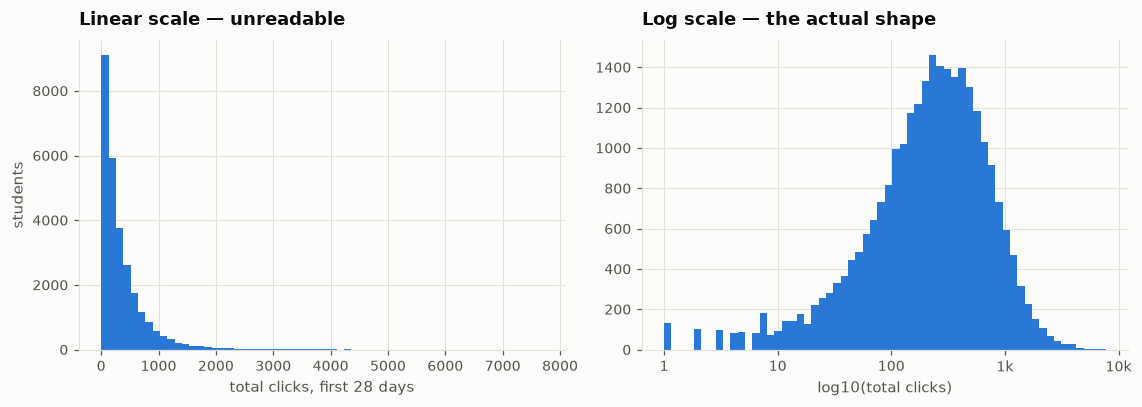

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.8))

ax1.hist(df["total_clicks"], bins=60, color=viz.NOT_AT_RISK)
ax1.set_title("Linear scale — unreadable")
ax1.set_xlabel("total clicks, first 28 days")
ax1.set_ylabel("students")

positive = df.loc[df["total_clicks"] > 0, "total_clicks"]
ax2.hist(np.log10(positive), bins=60, color=viz.NOT_AT_RISK)
ax2.set_title("Log scale — the actual shape")
ax2.set_xlabel("log10(total clicks)")
ax2.set_xticks([0, 1, 2, 3, 4], ["1", "10", "100", "1k", "10k"])

viz.show(fig)

The left panel is the classic beginner chart: one tall bar and a lot of
nothing. Every student is crammed into the first bin because a handful clicked
tens of thousands of times.

The right panel puts it on a **logarithmic scale**, where each step is a
multiplication rather than an addition (1 → 10 → 100 → 1,000). Now you can see
the real shape: roughly bell-shaped once you take logs, centred somewhere around
100–300 clicks, with a genuine left-hand group of very low-activity students.

That left-hand group is the interesting one.

## Does click volume separate the outcomes?

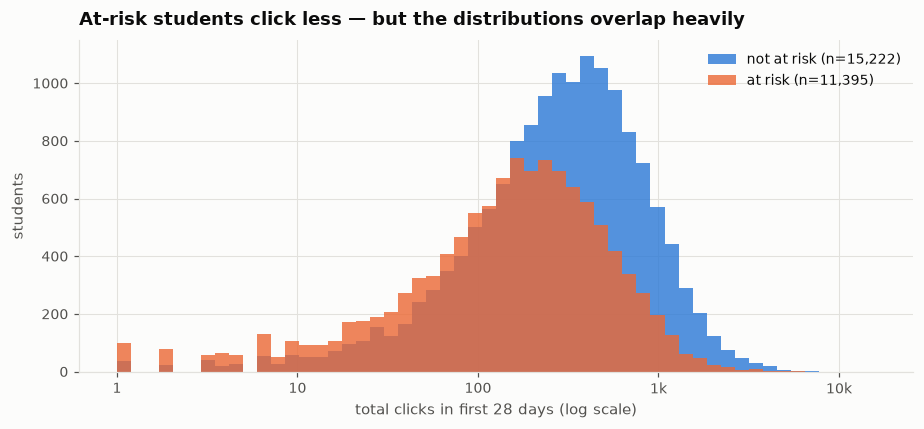

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 4.0))
bins = np.linspace(0, 4.2, 55)

for at_risk, color, name in [(0, viz.NOT_AT_RISK, "not at risk"),
                             (1, viz.AT_RISK, "at risk")]:
    sub = df[(df["at_risk"] == at_risk) & (df["total_clicks"] > 0)]
    ax.hist(np.log10(sub["total_clicks"]), bins=bins, color=color, alpha=0.8,
            label=f"{name} (n={len(sub):,})")

ax.set_xticks([0, 1, 2, 3, 4], ["1", "10", "100", "1k", "10k"])
ax.set_xlabel("total clicks in first 28 days (log scale)")
ax.set_ylabel("students")
ax.set_title("At-risk students click less — but the distributions overlap heavily")
ax.legend()
viz.show(fig)

In [5]:
summary = df.groupby("at_risk")[
    ["total_clicks", "active_days", "distinct_sites"]
].median()
summary.index = ["not at risk", "at risk"]
print("Medians, first 28 days:")
print(summary.round(1))

print()
for col in ["total_clicks", "active_days"]:
    zero = df.groupby("at_risk").apply(
        lambda g: (g[col] == 0).mean() * 100, include_groups=False
    )
    print(f"zero {col:14s}  not at risk {zero[0]:5.1f}%   at risk {zero[1]:5.1f}%")

Medians, first 28 days:
             total_clicks  active_days  distinct_sites
not at risk         298.0         16.0            27.0
at risk             152.0          9.0            19.0

zero total_clicks    not at risk   1.1%   at risk   6.2%
zero active_days     not at risk   1.1%   at risk   6.2%


**This is the single most important chart in the notebook**, and the lesson is
as much about the overlap as the difference.

Yes, at-risk students click about half as much at the median. But look at how
far the two histograms overlap. Plenty of at-risk students clicked a lot; plenty
of safe students clicked little.

That tells us something we need to carry forward: **no single number is going to
solve this problem.** Any model built on click volume alone will be mediocre,
because the distributions genuinely overlap. The hope has to be that combining
several weak signals produces something useful — which is exactly what the
model ladder in Phase 3 is designed to test.

If you had only seen the medians table, you might have expected an easy problem.
The chart tells the truth.

## Volume or consistency?

`active_days` (how many distinct days they showed up) separates about as well as
`total_clicks`. Those measure different things: someone could rack up 500 clicks
in one frantic session, or 500 clicks spread over 20 days.

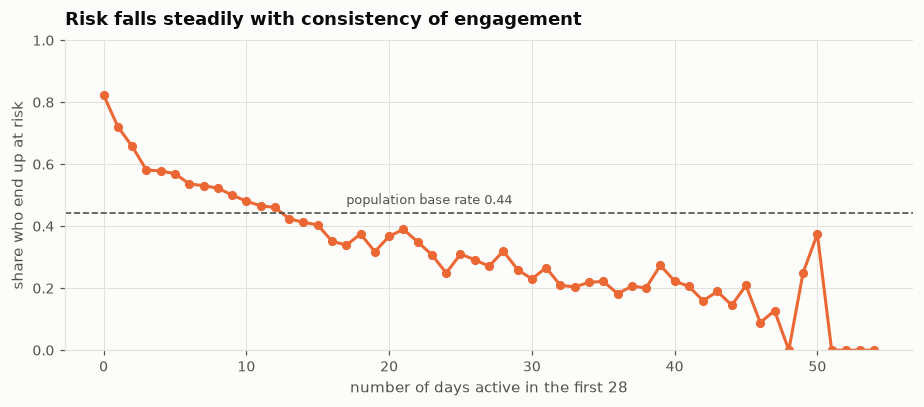

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 3.8))
counts = (
    df.groupby(["active_days", "at_risk"]).size().unstack(fill_value=0)
)
share = counts[1] / counts.sum(axis=1)
n_per_day = counts.sum(axis=1)

ax.plot(share.index, share.values, marker="o", color=viz.AT_RISK)
ax.axhline(df["at_risk"].mean(), color=viz.INK_SOFT, linestyle="--", linewidth=1.1)
ax.annotate(f"population base rate {df['at_risk'].mean():.2f}",
            xy=(17, df["at_risk"].mean() + 0.03), fontsize=8.5, color=viz.INK_SOFT)
ax.set_xlabel("number of days active in the first 28")
ax.set_ylabel("share who end up at risk")
ax.set_title("Risk falls steadily with consistency of engagement")
ax.set_ylim(0, 1)
viz.show(fig)

A clean, near-monotonic relationship: the more days a student shows up, the
lower their risk. It falls steeply over the first ten days and then flattens.

The flattening matters practically. Going from 2 active days to 8 tells you a
lot; going from 18 to 24 tells you comparatively little. A feature that captures
"showed up at all, regularly" may do most of the work of one that counts clicks
precisely.

## Part 2 — Trajectories

A single total throws away *when* the clicking happened. Two students with 200
clicks each look identical on volume, but one might be steady and the other
might have stopped after week one.

Let's put clicks into weekly buckets.

In [7]:
weekly = early.copy()
weekly["week"] = (weekly["date"] // 7).clip(lower=0)

per_week = (
    weekly.groupby(KEY + ["week"])["sum_click"].sum().reset_index()
)
per_week = per_week.merge(population[KEY + ["at_risk"]], on=KEY, how="inner")

means = per_week.groupby(["week", "at_risk"])["sum_click"].mean().unstack()
means.round(1)

at_risk,0,1
week,,
0,192.2,115.9
1,90.4,61.2
2,108.1,82.8
3,86.3,59.7
4,21.6,17.7


That table only covers the four weeks up to the cutoff. To see the shape of the
whole course — and to appreciate how much the model *cannot* see — let's plot
the full presentation, with the cutoff marked.

**This next chart deliberately uses data from after the cutoff.** It's
exploratory only; nothing derived from the right-hand side may become a
feature.

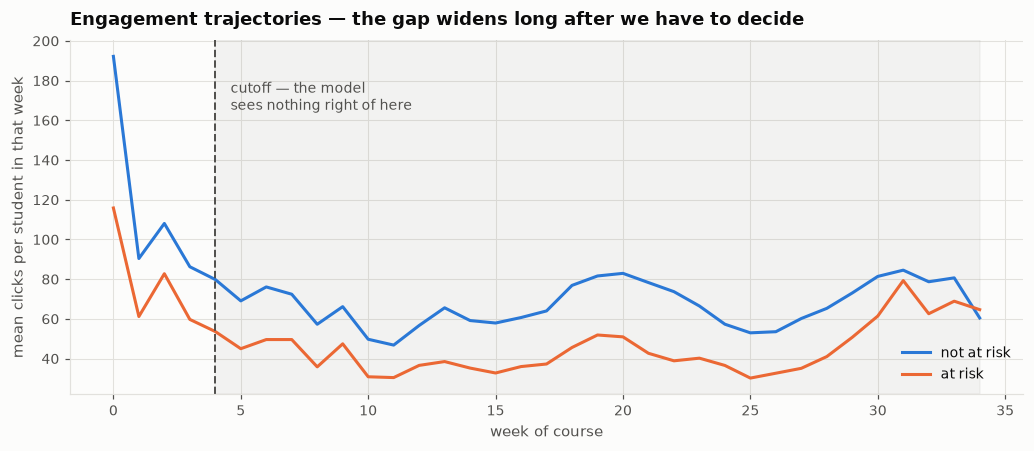

In [8]:
full = clicks.copy()
full["week"] = (full["date"] // 7).clip(lower=0)
full = full[full["week"] <= 34]

fw = full.groupby(KEY + ["week"])["sum_click"].sum().reset_index()
fw = fw.merge(population[KEY + ["at_risk"]], on=KEY, how="inner")
traj = fw.groupby(["week", "at_risk"])["sum_click"].mean().unstack()

fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.plot(traj.index, traj[0], color=viz.NOT_AT_RISK, label="not at risk")
ax.plot(traj.index, traj[1], color=viz.AT_RISK, label="at risk")

ax.axvspan(CUTOFF / 7, 34, color=viz.INK_SOFT, alpha=0.055)
ax.axvline(CUTOFF / 7, color=viz.INK_SOFT, linestyle="--", linewidth=1.3)
ax.annotate("cutoff — the model\nsees nothing right of here",
            xy=(CUTOFF/7 + 0.6, traj.max().max() * 0.86),
            fontsize=9, color=viz.INK_SOFT)

ax.set_xlabel("week of course")
ax.set_ylabel("mean clicks per student in that week")
ax.set_title("Engagement trajectories — the gap widens long after we have to decide")
ax.legend(loc="lower right")
viz.show(fig)

This chart is the project's central difficulty in one picture.

The two groups **do** separate — but the gap keeps widening for months. By week
20 it's obvious who's struggling. At week 4, where the dashed line sits, the
curves are close together.

That is the accuracy-versus-actionability trade-off made visual. Everything to
the right is information we're choosing not to use, because using it would mean
intervening too late to matter.

Notice too that both groups decline over the presentation. Engagement drops for
everyone; being at risk means declining *faster* from a *lower* start.

## Part 3 — What are they clicking on?

`studentVle` gives page IDs. The `vle` table says what each page *is*.

In [9]:
vle = tables["vle"]
typed = early.merge(vle[["id_site", "activity_type"]], on="id_site", how="left")

by_type = (
    typed.groupby(KEY + ["activity_type"])["sum_click"].sum().reset_index()
    .merge(population[KEY + ["at_risk"]], on=KEY, how="inner")
)

# Mean clicks per student per activity type, by outcome.
pivot = by_type.groupby(["activity_type", "at_risk"])["sum_click"].mean().unstack()
pivot["ratio"] = (pivot[1] / pivot[0]).round(2)
pivot = pivot.sort_values(0, ascending=False).head(12)
pivot.round(1)

at_risk,0,1,ratio
activity_type,,,
forumng,137.6,79.8,0.6
quiz,110.7,83.3,0.8
oucontent,103.0,63.5,0.6
homepage,87.2,54.1,0.6
subpage,47.0,34.7,0.7
ouwiki,26.3,17.3,0.7
resource,16.9,13.3,0.8
url,11.1,8.2,0.7
glossary,8.2,6.6,0.8


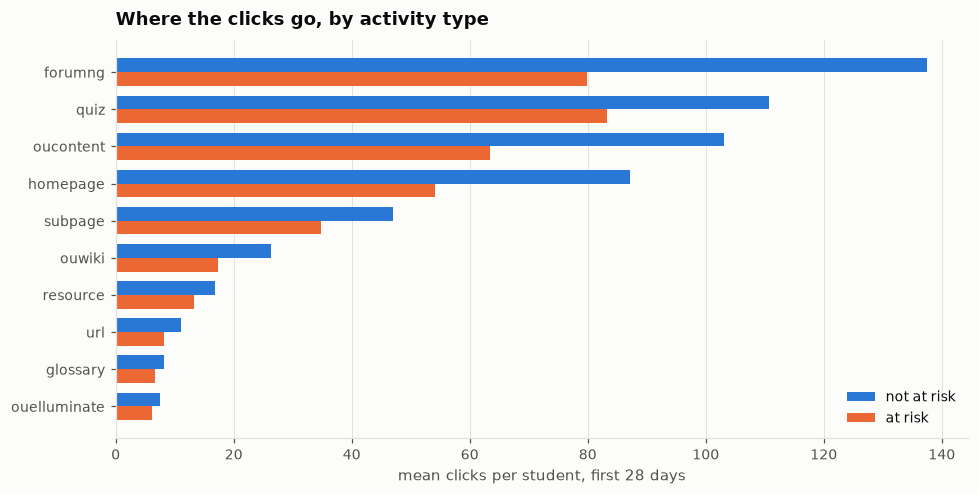

In [10]:
top = pivot.head(10).sort_values(0)

fig, ax = plt.subplots(figsize=(9.0, 4.6))
y = np.arange(len(top))
h = 0.37
ax.barh(y + h/2, top[0], height=h, color=viz.NOT_AT_RISK, label="not at risk")
ax.barh(y - h/2, top[1], height=h, color=viz.AT_RISK, label="at risk")
ax.set_yticks(y, top.index)
ax.set_xlabel("mean clicks per student, first 28 days")
ax.set_title("Where the clicks go, by activity type")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
viz.show(fig)

`oucontent` (course material) and `homepage` dominate the volume, which is
unsurprising. The `ratio` column in the table above is the more useful thing:
it's at-risk mean divided by not-at-risk mean, so **lower means the activity is
more strongly associated with doing well**.

Some activity types are used almost equally by both groups; others show a much
bigger gap. That variation is the argument for splitting clicks by type as a
feature rather than lumping them into one total — a hypothesis Phase 2 will
build and Phase 3 will test.

## Part 4 — Demographics

A caution before the numbers.

Everything below is an **association**: a pattern in how variables move
together. None of it establishes cause. If students from more deprived areas
show higher risk, that does not mean deprivation *causes* failure — the
relationship could run through funding, hours of paid work, caring
responsibilities, internet access, prior schooling, or something unmeasured.

This distinction is not pedantry. A model that treats association as cause, and
gets used to decide who deserves support, can entrench exactly the disadvantage
it appears to detect. Phase 4 has a fairness check for this reason.

### First, a check worth running on every categorical column

Before grouping by a category, confirm its values are the ones you think they
are. Compare what's in the file against the list you expect.

In [11]:
from oulad.schema import IMD_ORDER

in_file = set(population["imd_band"].dropna().unique())
expected = set(IMD_ORDER)

print("in the file but not expected:", sorted(in_file - expected))
print("expected but not in the file:", sorted(expected - in_file))
print()
print(f"categories matched: {len(in_file & expected)} of {len(expected)}")

in the file but not expected: []
expected but not in the file: []

categories matched: 10 of 10


Clean now — but this check earned its keep. **The raw OULAD file ships one
band as `10-20`, without the percent sign that every other band has.**

That affects 3,516 enrolments, about 11% of the dataset. And it fails *silently*:
code that filters or sorts by a clean list of band names simply drops those
students, with no error and no warning. A demographic gradient computed without
them would have had a hole in the second-most-deprived band and looked
perfectly plausible.

This project fixes it at load time — see `schema.VALUE_FIXES` and
`load.normalise_values` — rather than expecting everyone to remember. The check
above passes because the fix is applied; run it on the raw CSV and it fails.

**The general lesson:** a category that doesn't match your expected list doesn't
raise an error, it just quietly disappears from your results. Enumerate the
values of every categorical column before you group by it.

In [12]:
def risk_by(col, order=None):
    g = df.groupby(col, dropna=False)["at_risk"].agg(["mean", "size"])
    g.columns = ["at_risk_rate", "n"]
    if order:
        g = g.reindex([o for o in order if o in g.index])
    return g.round(3)


print("By index of multiple deprivation (0-10% = most deprived):")
print(risk_by("imd_band", IMD_ORDER))

By index of multiple deprivation (0-10% = most deprived):
          at_risk_rate     n
imd_band                    
0-10%            0.561  2650
10-20%           0.519  2824
20-30%           0.501  2984
30-40%           0.446  2999
40-50%           0.441  2715
50-60%           0.433  2690
60-70%           0.399  2511
70-80%           0.411  2517
80-90%           0.373  2380
90-100%          0.349  2240


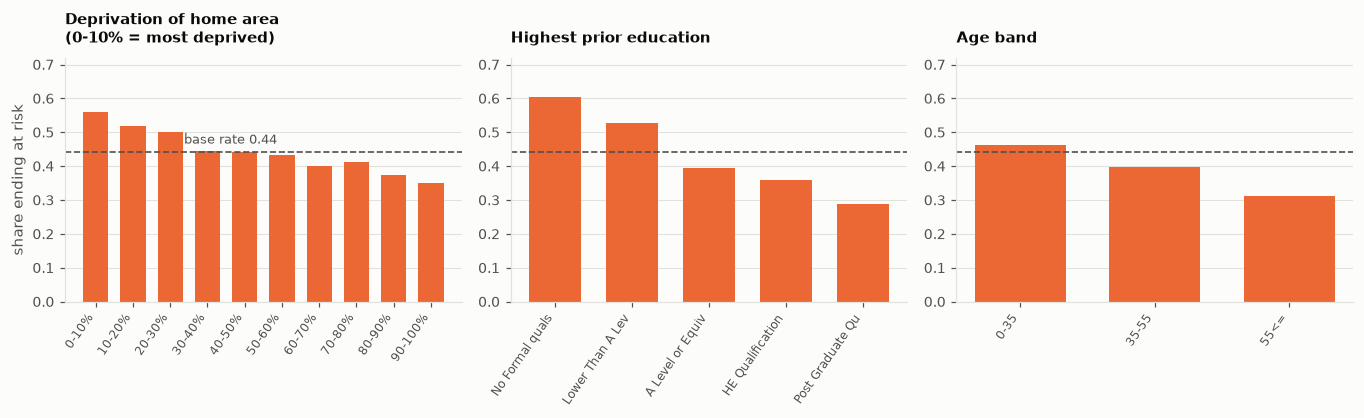

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.9))
base = df["at_risk"].mean()

specs = [
    ("imd_band", IMD_ORDER, "Deprivation of home area\n(0-10% = most deprived)"),
    ("highest_education", EDUCATION_ORDER, "Highest prior education"),
    ("age_band", AGE_ORDER, "Age band"),
]

for ax, (col, order, title) in zip(axes, specs):
    g = risk_by(col, order)
    ax.bar(range(len(g)), g["at_risk_rate"], color=viz.AT_RISK, width=0.68)
    ax.axhline(base, color=viz.INK_SOFT, linestyle="--", linewidth=1.1)
    labels_short = [str(i)[:16] for i in g.index]
    ax.set_xticks(range(len(g)), labels_short, rotation=55, ha="right", fontsize=8)
    ax.set_ylim(0, 0.72)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="x", visible=False)

axes[0].set_ylabel("share ending at risk")
axes[0].annotate(f"base rate {base:.2f}", xy=(0.30, base + 0.025),
                 xycoords=("axes fraction", "data"), fontsize=8.5,
                 color=viz.INK_SOFT)
viz.show(fig)

Three gradients, all in the direction you'd expect, none of them enormous:

- **Deprivation**: risk declines fairly steadily from most to least deprived.
- **Prior education**: a strong gradient — the largest of the three.
- **Age**: older students do somewhat better, which surprises people.

The dashed line is the population base rate (0.44). The education gradient is
the widest: 0.60 for students with no formal qualifications against 0.29 for
postgraduates — a roughly two-fold difference in risk. Deprivation spans 0.56 to
0.35, age 0.46 to 0.31.

Those are real effects, and larger than "modest" would suggest. But put them
next to the histogram from Part 1: even a two-fold difference in *rate* leaves
the two groups massively overlapping at the individual level. Knowing a
student's prior education shifts your estimate; it nowhere near determines the
outcome.

Two things follow. Demographics alone won't build a useful model. And because
they're modest, a model leaning heavily on them would be both weak *and*
ethically awkward — it would amount to flagging students for who they are
rather than what they're doing. Behaviour should carry the weight.

## Part 5 — Assessment behaviour

The last source: did they hand anything in?

In [14]:
assess = tables["assessments"]
subs = tables["studentAssessment"]

# Assessments due on or before the cutoff, excluding exams.
due_early = assess[
    (assess["date"] <= CUTOFF) & (assess["assessment_type"] != "Exam")
]
print(f"assessments due by day {CUTOFF}: {len(due_early)} "
      f"across {due_early[['code_module','code_presentation']].drop_duplicates().shape[0]} "
      "module-presentations")

sub_early = subs[subs["id_assessment"].isin(due_early["id_assessment"])].merge(
    due_early[["id_assessment", "code_module", "code_presentation", "date"]],
    on="id_assessment",
)
sub_early = sub_early[sub_early["date_submitted"] <= CUTOFF]

first = (
    sub_early.sort_values("date_submitted")
    .groupby(["id_student", "code_module", "code_presentation"], as_index=False)
    .first()
)
first["days_early"] = first["date"] - first["date_submitted"]

d2 = population.merge(first[KEY + ["score", "days_early"]], on=KEY, how="left")
d2["submitted"] = d2["score"].notna()

# Restrict to students whose course actually had something due by the cutoff --
# otherwise "did not submit" is confounded with "had nothing to submit".
courses_with_early = set(
    map(tuple, due_early[["code_module", "code_presentation"]].drop_duplicates().to_numpy())
)
d2["had_assessment_due"] = [
    (m, p) in courses_with_early
    for m, p in zip(d2["code_module"], d2["code_presentation"])
]

print()
print(f"students whose course had an assessment due by day {CUTOFF}: "
      f"{d2['had_assessment_due'].sum():,} of {len(d2):,}")
print()
print("Submission rate among those students:")
print(d2[d2["had_assessment_due"]].groupby("at_risk")["submitted"].mean().round(3)
      .rename({0: "not at risk", 1: "at risk"}).to_string())

assessments due by day 28: 17 across 16 module-presentations

students whose course had an assessment due by day 28: 22,548 of 27,538

Submission rate among those students:
at_risk
not at risk    0.980
at risk        0.784


In [15]:
got_score = d2[d2["submitted"]]
print(f"students with a first score by day {CUTOFF}: {len(got_score):,}")
print()
print("First assessment score:")
print(got_score.groupby("at_risk")["score"].describe()[
    ["count", "mean", "50%", "std"]].round(1))
print()
print("Days submitted before the deadline (negative = late):")
print(got_score.groupby("at_risk")["days_early"].median().round(1)
      .rename({0: "not at risk", 1: "at risk"}).to_string())

students with a first score by day 28: 20,074

First assessment score:
           count  mean   50%   std
at_risk                           
0        11977.0  77.0  80.0  20.1
1         8097.0  66.5  70.0  22.4

Days submitted before the deadline (negative = late):
at_risk
not at risk    1.0
at risk        0.0


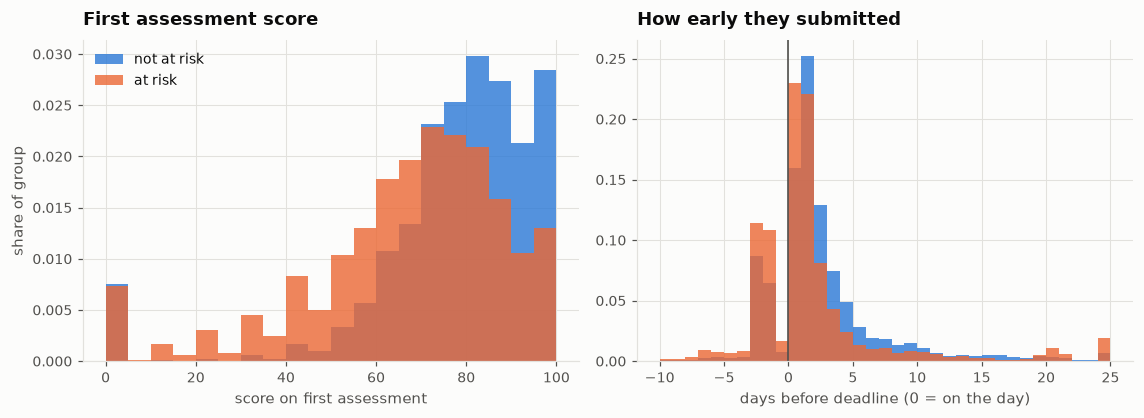

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.9))

for at_risk, color, name in [(0, viz.NOT_AT_RISK, "not at risk"),
                             (1, viz.AT_RISK, "at risk")]:
    sub = got_score[got_score["at_risk"] == at_risk]
    ax1.hist(sub["score"], bins=np.arange(0, 105, 5), color=color, alpha=0.8,
             label=name, density=True)
    ax2.hist(sub["days_early"].clip(-10, 25), bins=np.arange(-10, 26, 1),
             color=color, alpha=0.8, label=name, density=True)

ax1.set_xlabel("score on first assessment")
ax1.set_ylabel("share of group")
ax1.set_title("First assessment score")
ax1.legend()

ax2.axvline(0, color=viz.INK_SOFT, linewidth=1.1)
ax2.set_xlabel("days before deadline (0 = on the day)")
ax2.set_title("How early they submitted")

viz.show(fig)

Assessment behaviour looks like the strongest single signal we've seen.

Whether a student submitted at all separates the groups sharply. Among those who
did submit, at-risk students score lower and submit closer to the deadline.

There's a catch that limits how useful this is at day 28: **most modules don't
have an assessment due that early.** The count printed above is small. So this
feature is powerful where it exists and missing for most students — which is
itself a modelling problem, since "no assessment due yet" and "assessment due
and not submitted" mean completely different things and must not be encoded the
same way.

That's a real design issue for Phase 2, and exactly the sort of thing EDA is for
finding.

## What this suggests for feature engineering

Going into Phase 2, with reasons:

| Feature family | Why |
|---|---|
| **Volume** — total clicks, clicks per active day | Separates the groups, but weakly. Baseline material |
| **Consistency** — active days, longest gap | Cleaner monotonic relationship than raw volume |
| **Trajectory** — clicks per week, slope, days since last activity | Trajectories diverge; a single total hides direction |
| **Diversity** — clicks by activity type, distinct pages | Activity types differ in how much they separate |
| **Assessment** — submitted, score, days early | Strongest signal, but present for a minority at day 28. Needs careful missing-value handling |
| **Demographics** | Modest but real. Should support, not dominate |

And the honest caveat: every distribution we looked at **overlaps heavily**. No
single feature will do this on its own. Whether the combination is good enough
is the question Phase 3 exists to answer — and the trajectory chart suggests the
answer at week 4 will be "usefully better than chance, but far from certain".

## What to take away

1. **Click distributions are heavily skewed.** Use medians; plot on log scales.
2. **The groups differ but overlap enormously.** No single feature solves this.
3. **Consistency may matter as much as volume** — `active_days` shows a cleaner
   relationship than total clicks.
4. **Trajectories diverge mostly after the cutoff.** That is the core difficulty,
   not a fixable flaw.
5. **Assessment behaviour is the strongest signal** but is missing for most
   students at day 28.
6. **Demographics are real but modest**, and should not carry the model.

Next: Phase 2 — `build_features(cutoff_day)`, implementing the families above.